<div style="
  text-align: center;
  padding: 30px;
  background: linear-gradient(135deg, #0f2027, #203a43, #2c5364);
  border-radius: 20px;
  color: white;
  font-family: 'Orbitron', 'Segoe UI', sans-serif;
  font-size: 3.4em;
  font-weight: 900;
  letter-spacing: 2px;
  text-shadow: 0 0 10px #00ffe0, 0 0 20px #00ffe0;
">
CLASIFICADOR DE EMOCIONES MEDIANTE LA VOZ USANDO IA 🎤🧠
</div>

<link href="https://fonts.googleapis.com/css2?family=Orbitron:wght@600;900&display=swap" rel="stylesheet">


<p align="center">
  <center><img src="./Fotos/abejas_text.gif" alt="Esquema base" width="60%"></center>
</p>

<div style="background-color: #ffcccc; padding: 10px; border-radius: 8px; text-align: center; font-weight: bold; color: #990000; font-size: 3em;">
  ❗ IMPORTANTE ❗
</div>


Para asegurar el correcto funcionamiento de este cuaderno, es necesario que realices las siguientes acciones:
Descargar los documentos necesarios (carpeta ‘miniCrema’ y carpeta ‘Fotos’) junto al cuaderno.
Asegurar la correcta ejecución de la librería Tensorflow (da problemas con el entorno de la asignatura). Para ello, te planteamos 2 opciones para que escojas la que te sea más cómoda.

- *[RECOMENDADO]* Crear un **entorno nuevo** desde Anaconda Powershell Prompt con <font color="blue">conda create --name voz_provisional python=3.11</font> **|** <font color="blue">conda activate voz_provisional</font> **|** <font color="blue">conda install notebook</font> **|** <font color="blue">jupyter notebook</font> (lo podrás eliminar con <font color="blue">conda remove --name voz_provisional --all</font>) y ejecutar la celda con los “pip install” a continuación, una vez **iniciado el cuaderno desde el entorno nuevo**.
  
- Ejecutar la parte de tensorflow desde el siguiente cuaderno en **Google Colab**: https://colab.research.google.com/drive/1FNXhEnIQnIRiqg4vH2OfOkFWFzsOUZuN?usp=sharing y subir a tu **Drive** la carpeta ‘miniCrema’ (tarda 3-5min), indicando la ruta en el cuaderno en Colab. <font color="red">Si eliges esta opción, algunas celdas no funcionarán y printearán **'Versión sin Tensorflow'**, es normal.</font>

In [2]:
# !pip install pandas
# !pip install matplotlib
# !pip install librosa
# !pip install seaborn
# !pip install tqdm
# !pip install tensorflow
# !pip install git+https://github.com/speechbrain/speechbrain.git@v1.0.2
# !pip install transformers

# Índice

<div style="
  max-width: 400px;
  margin: 20px 0;
  font-family: 'Orbitron', 'Segoe UI', sans-serif;
  background: #1b2a38;
  border-radius: 12px;
  padding: 15px 25px;
  border-left: 5px solid #00bcd4;
  box-shadow: 2px 2px 8px #000000aa;
">
  <ul style="
    list-style-type: none;
    padding-left: 0;
    margin: 0;
  ">
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      1. Introducción
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      2. Inteligencia Artificial
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      3. Nuestro Dataset
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      4. Desarrollo del Proyecto
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      5. Juego de Clasificar Emociones
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      6. Relación con la Asignatura
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      7. Demo con modelo preentrenado
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      8. Implementaciones
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      border-bottom: 1px solid #0d3949;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      9. Conclusiones
    </li>
    <li style="
      color: #00bcd4;
      font-weight: 700;
      font-size: 1.3em;
      padding: 8px 0;
      cursor: pointer;
      transition: color 0.2s ease;
    " onmouseover="this.style.color='#00e5ff';" onmouseout="this.style.color='#00bcd4';">
      10. Bibliografía
    </li>
  </ul>
</div>

# 🟦 1. Introducción

El objetivo principal del proyecto es **clasificar un audio con voz según la emoción que transmite**.  
Para ello, nuestra solución se basa en el uso de la inteligencia artificial (Machine Learning y Deep Learning, concretamente) para entrenar un modelo capaz de **clasificar entre 6 emociones** distintas, definidas por la base de datos, de la que depende esta solución. La IA también se encargará de decidir qué características de los audios son las óptimas para su clasificación, así como los hiperparámetros con los que el modelo será entrenado.

<p>
  <center><img src="./Fotos/Esquema_base.png" alt="Esquema base" width="70%"></center>
</p>

<br><br>

#   🟨 2. Inteligencia Artificial

**¿Qué es la Inteligencia Artificial?**

La Inteligencia Artificial (IA) es el campo de estudio que busca crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Esto incluye actividades como razonar, planificar, reconocer patrones, entender el lenguaje y tomar decisiones. En resumen, la IA es el concepto general de lograr que las máquinas piensen o actúen de manera inteligente.

🤖 **IA = concepto general de hacer que las máquinas piensen o actúen inteligentemente.**

**¿Qué es el Machine Learning?**

Dentro de la IA, el Machine Learning (aprendizaje automático) es una subárea que se enfoca en diseñar algoritmos que permiten a las máquinas aprender directamente a partir de datos, sin necesidad de ser programadas explícitamente para cada tarea. Es decir, en lugar de decirle a la máquina exactamente qué hacer, se le enseñan ejemplos para que ella misma identifique patrones y tome decisiones basadas en ellos.

📊 **ML = forma de conseguir IA aprendiendo de los datos.**

**¿Y qué es el Deep Learning?**

El Deep Learning (aprendizaje profundo) es una rama más específica dentro del Machine Learning. Utiliza redes neuronales artificiales con muchas capas — conocidas como redes neuronales profundas — que son capaces de aprender representaciones muy complejas y abstractas de los datos. Esto permite a las máquinas abordar problemas mucho más difíciles, como reconocimiento avanzado de voz, imágenes o lenguaje natural.

🧠 **DL = técnica avanzada de ML basada en redes neuronales profundas**

<br><br>

#   🟥 3. Nuestro Dataset

Un dataset es básicamente una **base de datos**, en este caso de **+7000 audios de voz**, sobre la cual se apoyará la IA para entrenar el modelo con el objetivo mencionado anteriormente. Este dataset contiene audios etiquetados según la emoción que transmite el locutor al hablar.

### 🛠️ _Datos técnicos_

- **Las clases están balanceadas** — todas tienen el mismo número de archivos, excepto una. Además, todos los audios están muestreados a la misma frecuencia de 16 kHz (fs = 16 kHz).

<p align="center">
  <center><img src="./Fotos/Grafica_dataset.png" alt="Esquema base" width="70%"></center>
</p>

- **Espectrograma** de los audios del dataset en función de sus características.

Cargando...

--- Reproduciendo audio de la emoción: Angry ---


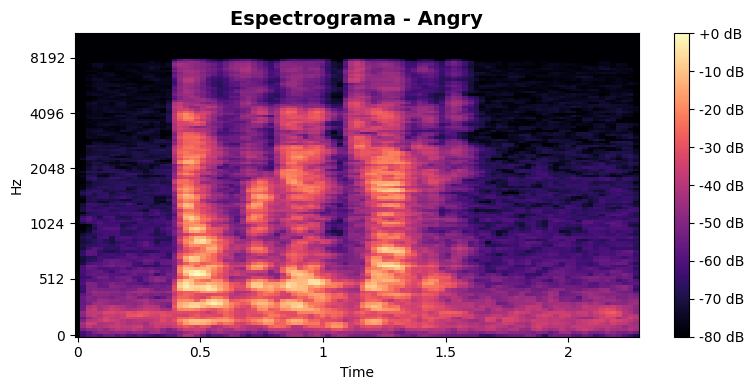


--- Reproduciendo audio de la emoción: Disgust ---


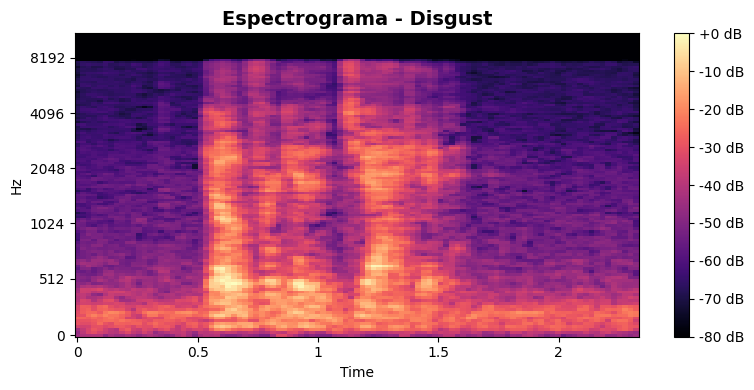


--- Reproduciendo audio de la emoción: Fear ---


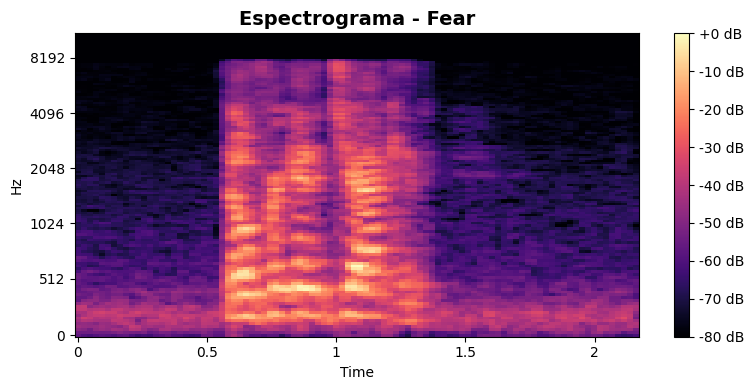


--- Reproduciendo audio de la emoción: Happy ---


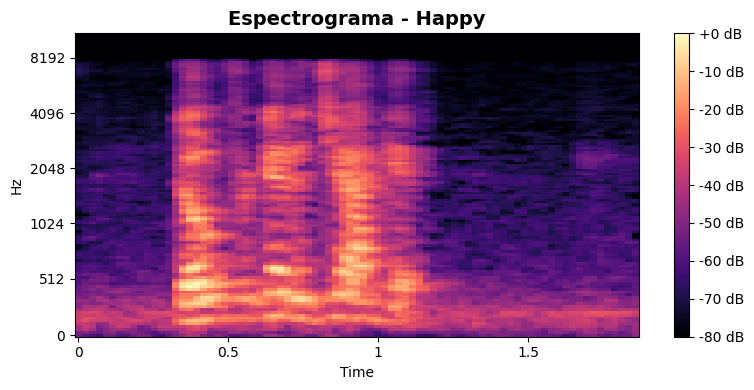


--- Reproduciendo audio de la emoción: Neutral ---


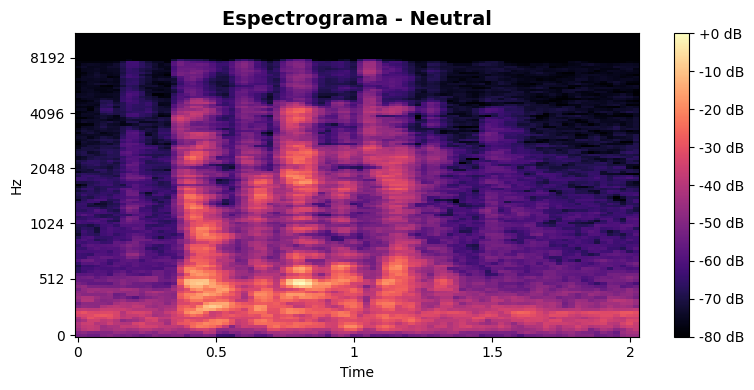


--- Reproduciendo audio de la emoción: Sad ---


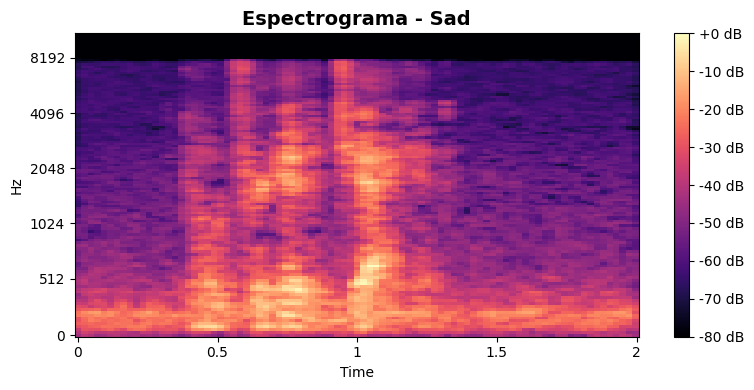

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt
#!pip install librosa soundfile
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np

# Mapeo de códigos a nombres de emociones
emociones = {
    "ANG": "Angry",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad"
}

# Diccionario para guardar un archivo por cada emoción
archivos_ejemplo = {}
carpeta_crema = "miniCrema"
# Recorremos los archivos .wav en la carpeta hasta encontrar uno por cada emoción
for archivo in os.listdir(carpeta_crema):
    if archivo.endswith(".wav"):
        partes = archivo.split("_")
        if len(partes) >= 3:
            codigo = partes[2]
            emocion = emociones.get(codigo)
            if emocion and emocion not in archivos_ejemplo:
                archivos_ejemplo[emocion] = os.path.join(carpeta_crema, archivo)
        if len(archivos_ejemplo) == len(emociones):
            break # Ya tenemos un archivo para cada emoción

# Reproducir un audio de cada clase y mostrar su espectrograma
print(f"Cargando...")
for emocion, ruta_audio in archivos_ejemplo.items():
    print(f"\n--- Reproduciendo audio de la emoción: {emocion} ---")

    # Reproducir el audio
    display(ipd.Audio(ruta_audio))

    # Cargar el audio y calcular el espectrograma
    y, sr = librosa.load(ruta_audio)
    spectrogram = librosa.feature.melspectrogram(y=y, sr=sr)
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

    # Mostrar el espectrograma
    plt.figure(figsize=(8, 4))
    librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Espectrograma - {emocion}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

- **Representación de los audios del dataset en función de sus características**

_Aclaración: Esta imagen es orientativa. Para construirla se han combinado diversas características extraídas (PCA); dependiendo de cuáles se seleccionen, la representación resultante puede variar._

<p>
  <center><img src="./Fotos/PCA_caracteristicas.png" alt="Esquema base" width="70%"></center>
</p>

<br></br>

#   🟩 4. Desarrollo del Proyecto

A lo largo del proyecto nos hemos enfrentado a **distintos retos** que hemos ido resolviendo paso a paso. Esta sección está pensada para que avances por las celdas como lo hicimos nosotros durante el desarrollo: explorando, experimentando y aprendiendo.

Verás imágenes, gráficos y pequeñas demostraciones interactivas que te permitirán entender mejor cómo tomamos decisiones y cómo evolucionó el sistema.

### 🔄 Cambios de Modelo: del Clásico al Profundo

Durante el proceso, probamos distintos **modelos de clasificación de audio**. Aquí te explicamos brevemente los más importantes y por qué fuimos cambiando de uno a otro:

🧠 **Support Vector Machine (SVM)**: Imagina que tienes puntos de dos clases en un espacio. SVM trata de **trazar una línea** (en 2D) **o un plano** (en más dimensiones) que maximice la distancia entre los puntos de distintas clases más cercanos.

<p>
  <center><img src="./Fotos/svm.png" alt="Esquema base" width="40%"></center>
</p>

Demasiado simple para un clasificador multiclase (6 clases, en nuestro caso). **La precisión alcanzaba un 46%**

🌲 **Random Forest (RF)**
Crea muchos árboles de decisión sobre subconjuntos aleatorios de datos y características (cada árbol aprende de una parte distinta). Cada árbol da un voto, y la clase final es la más votada (**clasificación por mayoría**).

<p>
  <center><img src="./Fotos/randomforestclassifier.jpg" alt="Esquema base" width="40%"></center>
</p>

Era una mejora respecto del anterior, pero no era suficiente quisimos ir más allá cambiando a una red neuronal, al ser un problema complejo el de clasificar emociones. **La precisión alcanzaba un 56%**

🔢 **MLP (Multilayer Perceptron)**
Imagina una red de personas pasándose notas entre sí, capa por capa. Cada persona en la red hace cálculos simples (como “si me llega un número alto, sumo 3 y paso el resultado”) y pasa el mensaje a la siguiente. Al final, la última persona da la respuesta (por ejemplo: "feliz"). Es como una **cadena de decisiones pequeñas** que lleva a una conclusión.  

Es decir, cada neurona toma un conjunto de entradas, las pondera, aplica una función no lineal (como ReLU o sigmoide) y pasa el resultado a la siguiente capa. Se entrena con backpropagation (ir hacia atrás por la red para corregir los errores en cada capa) y descenso del gradiente (técnica usada para ajustar los números internos (pesos) de la red neuronal, poco a poco, para cometer menos errores, como si estuvieras bajando una montaña poco a poco, guiándote por la inclinación del terreno).


<p>
  <center><img src="./Fotos/mlp.png" alt="Esquema base" width="40%"></center>
</p>

Los resultados mejoraron considerablemente, no obstante, aún queríamos buscar mejores predicciones, porque no estábamos satisfechos. **La precisión alcanzaba un 61%**

🧩 **CNN (Convolutional Neural Network)**
En vez de “mirar todo de golpe”, CNN revisa “pedazo por pedazo” para encontrar indicadores del rastro de cada clase. Después une todos esos datos para entender el todo. Como mirar un dibujo en detalle para decir qué representa.  

Usa **capas convolucionales que aplican filtros** para extraer características locales. Se combinan con capas de pooling (cogen la información más importante de una zona y la reducen, guardando sólo los datos relevantes) y luego se conectan a capas densas o Fully Connected (todas las neuronas están conectadas con todas las de la capa anterior para que la red tome decisiones con toda la información).

<p>
  <center><img src="./Fotos/cnn.png" alt="Esquema base" width="40%"></center>
</p>

<p>
  <center><img src="./Fotos/cnn2.png" alt="Esquema base" width="40%"></center>
</p>

Estos fueron los mejores resultados, obteniendo muy buena precisión. Aunque quizá era demasiada, ya que habían indicios de sobreentrenamiento (overfitting). **La precisión alcanzaba un 64%**

### 🔧 Ajustes Menores

Además de probar con distintos modelos, fuimos perfeccionando ciertos detalles para mantener cierta coherencia en el proceso y mejorar la precisión y optimización.

- **Normalización**: tanto los audios como las características extraídas de estos deben ser normalizados. En el caso de los audios, normalizamos en amplitud (entre -1 y 1) para trabajar con todos al “mismo nivel” y no realizar ninguna modificación más compleja que esa que pueda alterar los resultados para mal. 

    En cuanto a las características, se normalizan con Z-score. Este es un proceso que transforma los datos para que la media del conjunto de datos se vuelva 0 y la desviación estándar sea 1. Esto se logra usando la siguiente fórmula para cada valor x:

<center>$X_{\text{normalizado}} = \frac{x - \mu}{\sigma}$</center>

- **Resampling**: es el proceso mediante el cual se “remuestrea” una señal para cambiar su frecuencia de muestreo. En nuestro caso, todos los audios del dataset tienen la misma frecuencia de muestreo. No obstante, no deja de ser un valor a tener en cuenta por si no fuera así o por si los audios con los que se quiera testear posteriormente no están muestreados de la misma manera.

- **Data augmentation**: consiste en crear nuevas muestras (audios) a partir de las ya existentes en la base de datos para complementar a esta, es decir, balancearla (compensar las clases que tienen menos audios) y aumentar su precisión (cuantos más audios, mejores resultados). Para ello, existen diversos métodos como cambiar el pitch de los audios (pitch shifting), añadirles ruido o cambiar su velocidad (time stretching).

- **Paralelización del proceso**: mediante el uso de librerías, es posible paralelizar los cálculos que lo permitan (entrenamiento de la red neuronal) para que el tiempo de procesado sea mucho menor.

### 🧪 MiniTraining

Vamos a realizar una demo utilizando un subconjunto reducido del dataset original: MiniCrema, que contiene aproximadamente **400 archivos de audio**. Este tamaño es demasiado pequeño para entrenar un modelo robusto en un caso real, pero se utiliza aquí con fines demostrativos, ya que emplear el dataset completo implicaría tiempos de entrenamiento mucho más elevados.

Además, compararemos los resultados al aplicar un modelo de aprendizaje automático tradicional como **Random Forest** frente a una red neuronal profunda como la **CNN**.

#### 🌲 Random Forest


- Requiere extraer manualmente las características del audio (MFCCs, pitch, ZCR, etc.).

- No entiende estructuras espaciales o temporales complejas.

- Bueno para datos tabulares (vectores) y cuando el dataset no es muy grande.

- Más rápido de entrenar, fácil de interpretar.

- No necesita GPU.

Entrenaremos un modelo de Random Forest utilizando el conjunto de datos miniCrema, que contiene **400 archivos de audio**. Dividiremos estos datos en un conjunto de _entrenamiento_ (train 80%) y otro de _prueba_ (test 20%) y entrenaremos el modelo con los mejores hiperparametros obtenidos mediante un estudio previo. Finalmente, evaluaremos el rendimiento del modelo visualizando la matriz de confusión sobre los datos de prueba para analizar mejor los resultados.

In [5]:
import os
import logging
from joblib import Parallel, delayed
import librosa
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

              precision    recall  f1-score   support

       angry       0.42      0.57      0.48        14
     disgust       0.36      0.29      0.32        14
        fear       0.40      0.29      0.33        14
       happy       0.36      0.29      0.32        14
     neutral       0.46      0.50      0.48        12
     sadness       0.50      0.64      0.56        14

    accuracy                           0.43        82
   macro avg       0.42      0.43      0.42        82
weighted avg       0.42      0.43      0.42        82



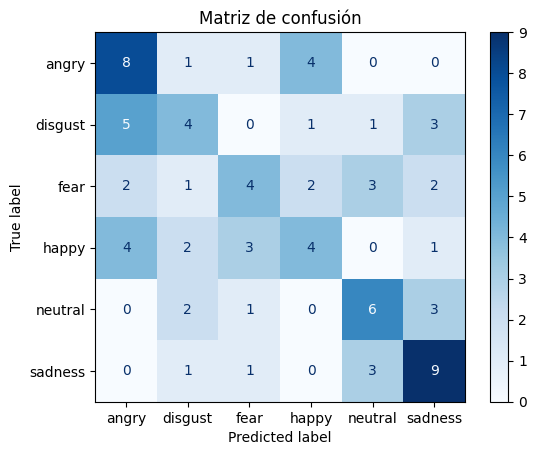

In [6]:
# Configuración de logging (usado para un resultado más vistoso)
def setup_logger():
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[logging.StreamHandler()]
    )
    return logging.getLogger(__name__)

logger = setup_logger()

def extract_basic_features(audio, sr):
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    rmse = librosa.feature.rms(y=audio)
    spec_cent = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spec_bw = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(audio)
    feats = [
        np.mean(chroma), np.std(chroma),
        np.mean(rmse), np.std(rmse),
        np.mean(spec_cent), np.std(spec_cent),
        np.mean(spec_bw), np.std(spec_bw),
        np.mean(rolloff), np.std(rolloff),
        np.mean(zcr), np.std(zcr)
    ]
    return feats


def extract_mfcc_features(audio, sr, n_mfcc=20):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    feats = []
    for e in mfcc:
        feats.extend([np.mean(e), np.std(e)])
    return feats


def extract_audio_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=None)
        audio = librosa.util.normalize(audio,norm=np.inf) # Normaliza dividiendo por el valor absoluto máximo (peak normalization).
        # audio = normalize_audio(audio)
        feats = extract_basic_features(audio, sr)
        feats.extend(extract_mfcc_features(audio, sr))
        return feats
    except Exception as e:
        logger.warning(f"Error procesando {file_path}: {e}")
        return None

# 2. Procesar dataset (en paralelo)

def process_dataset(dataset_path):
    """
    descripcion de funcion!!!!
    
    Parámetros de entrada:
    > dataset_path: 
    
    Devuelve:
    > df: data frame de los datos de las características y su nombre correspondiente (csv)
    > y : lista de las emociones etiquetadas en el entrenamiento (csv)
    """
    
    # Búsqueda de los audios del dataset en 'dataset_path'
    files = [f for f in os.listdir(dataset_path) if f.endswith('.wav')]
    
    # Mapa de emociones (en función del diseño del dataset)
    emotion_map = {'SAD':'sadness','ANG':'angry','DIS':'disgust','FEA':'fear','HAP':'happy','NEU':'neutral'}
    
    # Función para extraer la etiqueta de cada audio (emotion) y sus características o features (feats)
    def process_file(f):
        code = f.split('_')[2]
        emotion = emotion_map.get(code)
        if not emotion:
            return None, None
        feats = extract_audio_features(os.path.join(dataset_path, f))
        return feats, emotion

    results = Parallel(n_jobs=-1)(delayed(process_file)(f) for f in files)
    feats_list, emotions = zip(*[r for r in results if r[0] is not None])
    
    # Almacenamiento de características extraídas y emociones etiquetadas en csv
    basic_cols = ['chroma_mean','chroma_std','rmse_mean','rmse_std',
                  'spec_cent_mean','spec_cent_std','spec_bw_mean','spec_bw_std',
                  'rolloff_mean','rolloff_std','zcr_mean','zcr_std']
    mfcc_mean  = [f'mfcc{i}_mean' for i in range(1,21)]
    mfcc_std   = [f'mfcc{i}_std' for i in range(1,21)]
    cols = basic_cols + mfcc_mean + mfcc_std

    df = pd.DataFrame(feats_list, columns=cols)
    y  = pd.Series(emotions, name='emotion')
    return df, y

# 3. Pipeline, entrenamiento y evaluación
def train_and_evaluate(df, y, test_size=0.2, random_state=42):
    # División en datos (X) y etiquetas (y) y en entrenamiento/testing
    X_train, X_test, y_train, y_test = train_test_split(
        df, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),                             # Normalización de características
        ('pca', PCA(n_components=0.95)),                          # Reducción de dimensionalidad
        ('rf', RandomForestClassifier(                            # Modelo con hiperparámetros ya optimizados
            class_weight='balanced_subsample', 
            max_depth=20, 
            max_features='sqrt', 
            min_samples_leaf=1,
            min_samples_split=10, 
            n_estimators=400,
            random_state=42
        ))
    ])
    
    # Entrenamiento directo con los mejores parámetros ya conocidos
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    # Evaluación del modelo
    print(classification_report(y_test, preds))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, preds, labels=pipe.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
    disp.plot(cmap='Blues')
    plt.title('Matriz de confusión')
    plt.show()

    return pipe, X_train, X_test, y_train, y_test


# 4. Ejecución principal
def main():
    dataset_path = 'miniCrema'
    df, y = process_dataset(dataset_path)
    df.to_csv('audio_features.csv', index=False)
    y.to_csv('emotion_labels.csv', index=False)

    pipeline, X_train, X_test, y_train, y_test = train_and_evaluate(df, y)


if __name__ == '__main__':
    main()

Podemos observar que el modelo ha alcanzado una precisión aproximada del 45%. En la matriz de confusión se aprecia que, aunque el modelo acierta la mayoría de las veces, hay ciertas emociones que resultan más difíciles de clasificar correctamente.

Si utilizáramos el dataset completo, la matriz de confusión tendría el siguiente aspecto:

<p align="center">
  <img src="./Fotos/minicrema_randomforest.png" alt="Esquema base" width="70%">
</p>

#### 🧩 CNN > Abrir en Google Colab si no has creado el entorno

- Puede aprender automáticamente patrones espaciales o temporales en los datos (como espectrogramas o secuencias de MFCCs).

- Ideal para datos estructurados como imágenes o mapas de calor de audio.

- Más potente para reconocer relaciones complejas y sutiles.

- Requiere más datos y tiempo de entrenamiento.

- Puede beneficiarse de usar GPU.

Vamos ahora a plicar la misma logica pero con una red neuronal: CNN **(Este proceso tardará unos minutos 😬😬)**

In [7]:
try:
    import os
    import librosa
    import numpy as np
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    from joblib import Parallel, delayed
    from sklearn.preprocessing import LabelEncoder
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import tensorflow as tf
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import load_model, Model
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.layers import (
        Input, Conv1D, MaxPooling1D, Dropout, BatchNormalization,
        Bidirectional, LSTM, Dense, Masking, GlobalAveragePooling1D, Layer
    )
    from tensorflow.keras.callbacks import (
        EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
    )
    import pickle
except:
    print("Versión sin Tensorflow")

In [8]:
# ---------------------------------------------------------------------------
# Capa de Atención personalizada
# ---------------------------------------------------------------------------
try:
    class Attention(tf.keras.layers.Layer):
        def __init__(self, **kwargs):
            super(Attention, self).__init__(**kwargs)
        def build(self, input_shape):
            self.W = self.add_weight(
                name="att_weight", shape=(input_shape[-1], input_shape[-1]),
                initializer="glorot_uniform", trainable=True
            )
            self.b = self.add_weight(
                name="att_bias", shape=(input_shape[-1],),
                initializer="zeros", trainable=True
            )
            self.u = self.add_weight(
                name="att_u", shape=(input_shape[-1], 1),
                initializer="glorot_uniform", trainable=True
            )
            super(Attention, self).build(input_shape)
        def call(self, inputs):
            u_it = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
            a_it = tf.tensordot(u_it, self.u, axes=1)
            a_it = tf.squeeze(a_it, -1)
            alpha = tf.nn.softmax(a_it, axis=1)
            alpha_expanded = tf.expand_dims(alpha, -1)
            return tf.reduce_sum(inputs * alpha_expanded, axis=1)
        def compute_output_shape(self, input_shape):
            return (input_shape[0], input_shape[-1])

    # ---------------------------------------------------------------------------
    # Data Augmentation: ruido gaussiano + time shift
    # ---------------------------------------------------------------------------
    def augment_signal(signal, sr=16000, snrDB=20):
        np.random.seed(0)
        # + Noise
        SNR=10**(snrDB/10) # Determinamos la relación señal a ruido que habrá en la señal degradada
        PotxDB=10*np.log10(np.mean(np.square(np.float64(signal))))
        Potr=PotxDB-snrDB
        potr=10**(Potr/10)  # potencia media del ruido en unidades lineales

        noise=np.sqrt(potr)*np.random.randn(len(signal))
        signalMod1 = signal + noise

        # + Time Stretch
        signalMod2 = librosa.effects.time_stretch(np.float64(signalMod1), rate=np.random.uniform(0.8, 1.2))
        # + Pitch Shift
        # signalMod3 = librosa.effects.pitch_shift(np.float64(signalMod1), sr=sr, n_steps=np.random.uniform(-1.5, 1.5))

        return signalMod2


    # ---------------------------------------------------------------------------
    # Extracción de características: MFCC + Delta + Delta-Delta
    # ---------------------------------------------------------------------------
    def extract_audio_features(file_path, n_mfcc=13, duration=3, offset = 0.5, sr=16000, augment=False):
        # try:
        audio, _ = librosa.load(file_path, sr=sr, mono=True, duration=duration, offset=offset)
        if augment:
            audio = augment_signal(audio,sr)
        audio = librosa.util.normalize(audio)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        zcr = librosa.feature.zero_crossing_rate(audio)
        rms = librosa.feature.rms(y=audio)
        roll = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        cent = librosa.feature.spectral_centroid(y=audio, sr=sr)

        return np.vstack([mfcc, delta, delta2, zcr, rms, roll, cent]).T
        # except Exception as e:
        #     print(f"Error procesando {file_path}: {e}")
        #     return None

    # ---------------------------------------------------------------------------
    # Procesamiento del dataset: devuelve features, labels y filenames
    # ---------------------------------------------------------------------------
    def process_dataset(dataset_path,sr=16000,dur=3,offset=0.5):
        files = [f for f in os.listdir(dataset_path) if f.endswith('.wav')]
        emotion_map = {
            'SAD': 'sadness', 'ANG': 'angry', 'DIS': 'disgust',
            'FEA': 'fear',    'HAP': 'happy',  'NEU': 'neutral'
        }
        feats, labels, fnames = [], [], []
        for f in tqdm(files, desc="Extrayendo features"):  
            parts = f.split('_')
            code = parts[2] if len(parts) >= 3 else None
            emo = emotion_map.get(code)
            if not emo:
                continue
            feat = extract_audio_features(os.path.join(dataset_path, f),sr,dur,offset)
            if feat is not None:
                feats.append(feat)
                labels.append(emo)
                fnames.append(f)
        return feats, labels, fnames

    # ---------------------------------------------------------------------------
    # Construcción del modelo: CNN + BiLSTM + Atención
    # ---------------------------------------------------------------------------
    def build_model(input_shape, num_classes):
        inp = Input(shape=input_shape)
        x = Masking(mask_value=0.0)(inp)
        x = Conv1D(128, 5, padding='same', activation='relu', kernel_regularizer=l2(1e-3))(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(2)(x)
        x = Dropout(0.4)(x)
        x = Conv1D(64, 3, padding='same', activation='relu', kernel_regularizer=l2(1e-3))(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(2)(x)
        x = Dropout(0.4)(x)
        x = Bidirectional(LSTM(64, return_sequences=True))(x)
        x = Dropout(0.5)(x)
        x = Attention()(x)  # suponiendo que devuelve (batch, features)
        out = Dense(num_classes, activation='softmax')(x)
        model = Model(inp, out)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='categorical_crossentropy', metrics=['accuracy']
        )
        return model


    # ---------------------------------------------------------------------------
    # Bloque principal con split antes de augmentación
    # ---------------------------------------------------------------------------
    def train(data_path,sr,dur,offset):
        DATA_PATH = data_path
        SAMPLE_RATE = sr
        DURATION = dur
        OFFSET = offset

        # 1) Extraer solo datos originales
        feats_orig, labels_orig, files_orig = process_dataset(DATA_PATH,SAMPLE_RATE,DURATION,OFFSET)

        # 2) Separar test (20%) y train0 (80%) solo originales    
        files_train0, files_test, y_train0_text, y_test_text = train_test_split(
            files_orig, labels_orig, test_size=0.2, stratify=labels_orig, random_state=42
        )
        # Construir mapas de features y labels
        feat_map = dict(zip(files_orig, feats_orig))
        label_map = dict(zip(files_orig, labels_orig))
        X_train0 = [feat_map[f] for f in files_train0]
        X_test   = [feat_map[f] for f in files_test]
        y_train0 = y_train0_text
        y_test   = y_test_text

        # 3) Generar aumentación SOLO sobre train0
        X_aug, y_aug = [], []
        for f in tqdm(files_train0, desc="Augment training set"):
            feat_aug = extract_audio_features(os.path.join(DATA_PATH, f),sr,dur,offset, augment=True)
            if feat_aug is not None:
                X_aug.append(feat_aug)
                y_aug.append(label_map[f])

        # Combinar train original + augmentado
        X_train = X_train0 + X_aug
        y_train_text = y_train0 + y_aug

        # 3.5) Normalización de características
        def normalize_sequence(seq, mean, std):
            return (seq - mean) / std

        # Normalizar cada secuencia (X_train y X_test)
        all_feats = np.concatenate([seq for seq in feats_orig], axis=0)
        mean = np.mean(all_feats, axis=0)            # Shape: (n_features,)
        std = np.std(all_feats, axis=0) + 1e-8       # Sumar epsilon para evitar división por cero

        X_train = [normalize_sequence(seq, mean, std) for seq in X_train]
        X_test  = [normalize_sequence(seq, mean, std)  for seq in X_test]

        # 4) Zero-Padding al final
        max_len = max([x.shape[0] for x in X_train + X_test])
        X_train = pad_sequences(X_train, maxlen=max_len, padding='post', dtype='float32')
        X_test  = pad_sequences(X_test, maxlen=max_len, padding='post', dtype='float32')


        # 5) Etiquetas one-hot
        le = LabelEncoder().fit(labels_orig)
        y_train_int = le.transform(y_train_text)
        y_test_int  = le.transform(y_test_text)
        y_train = tf.keras.utils.to_categorical(y_train_int)
        y_test  = tf.keras.utils.to_categorical(y_test_int)

        # 6) Construir y entrenar
        model = build_model((X_train.shape[1], X_train.shape[2]), y_train.shape[1])
        callbacks = [
            EarlyStopping('val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau('val_loss', 0.5, patience=4),
            ModelCheckpoint('best_model.h5', save_best_only=True),
            TensorBoard(log_dir='./logs')
        ]
        history = model.fit(
            X_train, y_train, validation_split=0.1,
            epochs=30, batch_size=32, callbacks=callbacks
        )

        # 7) Evaluación y guardado
        loss, acc = model.evaluate(X_test, y_test)
        print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")
        model.save('emotion_model_final.h5')
        pickle.dump(le, open('label_encoder.pkl','wb'))

        # Curva de pérdida
        plt.figure(figsize=(8,5))
        plt.plot(history.history['loss'], label='train')
        plt.plot(history.history['val_loss'], label='val')
        plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.show()

        # Confusion Matrix Generation and Display
        # Predict probabilities for the test set
        y_pred_probs = model.predict(X_test)
        # Convert probabilities to class labels
        y_pred_int = np.argmax(y_pred_probs, axis=1)

        # Get the true class labels
        # y_test_int is already the integer representation of the true labels
        # le.classes_ gives the original string labels in the order they were encoded

        # Compute the confusion matrix
        cm = confusion_matrix(y_test_int, y_pred_int)

        # Display the confusion matrix
        fig, ax = plt.subplots(figsize=(10, 10))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
        disp.plot(cmap=plt.cm.Blues, ax=ax)
        plt.title('Confusion Matrix')
        plt.show()
except:
    print("Versión sin Tensorflow")

Augment training set: 100%|██████████████████████████████████████████████████████████| 327/327 [00:35<00:00,  9.15it/s]
C:\Users\Marcos\anaconda3\envs\voz_provisional\Lib\site-packages\keras\src\layers\layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2143 - loss: 2.0495

2025-05-30 18:45:21,929 [WARNING] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.2162 - loss: 2.0479 - val_accuracy: 0.1364 - val_loss: 2.1606 - learning_rate: 0.0010
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4367 - loss: 1.7773

2025-05-30 18:45:25,460 [WARNING] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


...

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.9942 - loss: 0.3323 - val_accuracy: 0.9394 - val_loss: 0.4887 - learning_rate: 5.0000e-04
Epoch 18/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9973 - loss: 0.3096

2025-05-30 18:46:08,931 [WARNING] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9972 - loss: 0.3099 - val_accuracy: 0.9545 - val_loss: 0.4713 - learning_rate: 5.0000e-04
Epoch 19/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9944 - loss: 0.3086 - val_accuracy: 0.9545 - val_loss: 0.4907 - learning_rate: 5.0000e-04
Epoch 20/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.9944 - loss: 0.3032 - val_accuracy: 0.9545 - val_loss: 0.4790 - learning_rate: 5.0000e-04
Epoch 21/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.9939 - loss: 0.3048 - val_accuracy: 0.9545 - val_loss: 0.4731 - learning_rate: 5.0000e-04
Epoch 22/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9996 - loss: 0.2926 - val_accuracy: 0.9545 - val_loss: 0.4810 - learning_rate: 5.0000e-04
Epoch 23/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.9973 - loss: 0.2927 - val_accuracy: 0.9545 - val_loss: 0.5009 - learning_rate: 2.5000e-04
Epoch 24/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.999

2025-05-30 18:46:33,391 [WARNING] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Test Loss: 2.9512, Test Accuracy: 0.4390


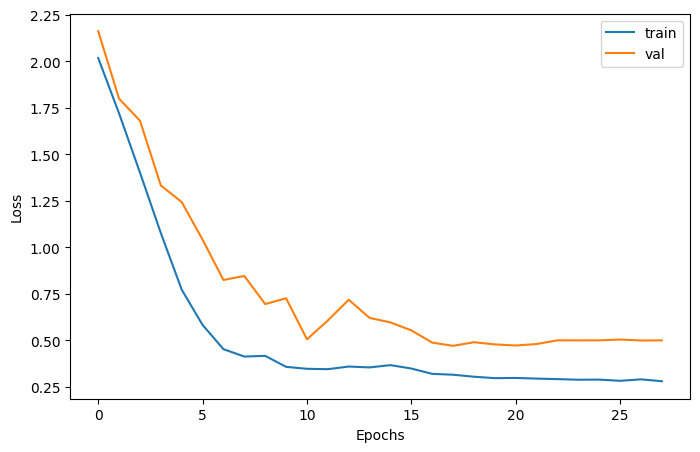

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 481ms/step


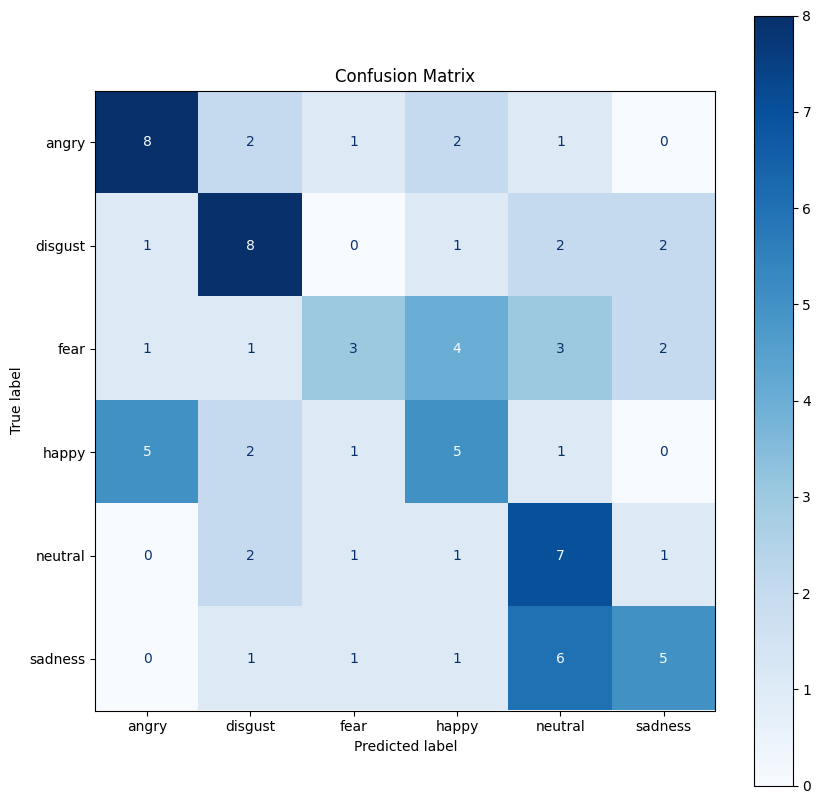

In [9]:
try:
    # Ejecutar entrenamiento del modelo a partir de un dataset
    DATA_PATH = './miniCrema'  # Ruta al dataset
    SAMPLE_RATE = 16000        # Frecuencia de muestreo para resampling
    DURATION = 3               # Duración media de los audios
    OFFSET = 0.3               # Silencio supuesto al inicio y final de los audios

    if __name__ == '__main__':
        train(DATA_PATH,SAMPLE_RATE,DURATION,OFFSET)
except:
    print("Versión sin Tensorflow")

### 📐 Esquema de la Solución Final (CNN)


<center><img src="./Fotos/esquema_cnn.png" alt="Esquema cnn" width="80%"></center

#### 🔉 1. Preprocesado del Audio
- El audio se carga y recorta a una duración estándar.
- Se convierte a mono y se resamplea a una frecuencia común.
- Se normaliza la amplitud para que todos los audios tengan la misma escala.

#### 🎚️ 2. Extracción de Características
- El audio se transforma en números que representan su contenido.
- Se extraen elementos como tono, ritmo y cambios en la voz.
- Esto es lo que el modelo usa para aprender.

#### 🔊 3. Aumento de Datos (Data Augmentation)
- Se generan versiones modificadas de los audios originales.
- Ejemplo: añadir ruido para simular condiciones reales.
- Ayuda a que el modelo no se "memorice" los datos, sino que aprenda a generalizar.

#### 🧱 4. Construcción del Modelo
- Se combina:
  - CNN para detectar patrones locales.
  - BiLSTM para entender cómo cambian en el tiempo.
  - Atención para centrarse en lo importante.
- El modelo aprende a reconocer emociones complejas en los audios.

#### 🔄 5. Flujo General del Entrenamiento
- Se cargan los datos y se preparan.
- Se divide el conjunto en entrenamiento y prueba.
- Solo los audios de entrenamiento se modifican con aumentación.
- Se ajustan las secuencias para que tengan todas el mismo tamaño.
- Se convierten las etiquetas emocionales en formato comprensible para el modelo.
- Se entrena el modelo controlando que no aprenda de más (overfitting).
- Se guarda el modelo final y todo lo necesario para usarlo en el futuro.

#### 📊 6. Evaluación y Visualización
- Se prueba el modelo con audios no vistos.
- Se dibujan gráficas para ver cómo ha ido aprendiendo a lo largo del tiempo.
  - Curva de pérdidas
  - Diagrama de confusión


# 🟪 5. Juego de Clasificar Emociones

Ahora ya entiendes cómo lo hace una máquina pero, **¿podrás conseguir una precisión superior mediante tu propio juicio humano?**

Al ejecutar el siguiente código, se te abrirá una **ventana aparte en la barra de tareas** con la que seleccionarás la emoción que creas que correponda con el audio generado por el código:

In [2]:
import os
import random
import IPython.display as ipd
import tkinter as tk
from tkinter import ttk, messagebox
import threading
import scipy.io.wavfile as wav

def lee_audio(fichero):
    """Lee fichero de audio wav (devuelve frecuencia de muestreo y array)
    Argumentos de Entrada:
        fichero (String): Cadena con la rura y el archivo de audio en formato wav
        
    Salida:
        fs (float): frecuencia de muestreo del audio
        x (np.ndarray): variable con las muestras de la señal de audio
    """    
    fs,x = wav.read(fichero)
    return fs,x

def sonido(x,fs,m='none'):
    """Abre un interfaz para la reproducción de auido
    Argumentos de Entrada:
        x (np.ndarray): variable con la forma de onda de la señal a reproducir
        fs (float): frecuencia de muestreo de la señal a reproducir
        m (variable): Por defecto vacía, y el audio se reproducirá normalizado respecto su máximo valor absoluto. En otro caso, indica el reproductor que normalice el audio respecto del formato int16
    """
    if m!='none':
        x=x.astype(np.float64)
        x=x/2**15
        ipd.display(ipd.Audio(x.T,rate=fs,normalize=False))
    else:
        ipd.display(ipd.Audio(x.T,rate=fs))

# Configuración inicial
EMOTION_MAP = {
    'SAD': 'sadness',
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral'
}

class EmotionGame:
    def __init__(self, root):
        self.root = root
        self.root.title("Juego de Emociones")
        self.root.geometry("400x400")
        
        self.dataset_path = './miniCrema'
        self.samples = self.select_random_audios()
        self.current_sample = 0
        self.score = 0
        
        self.create_widgets()
        self.play_next_audio()
    
    def select_random_audios(self):
        files = [f for f in os.listdir(self.dataset_path) if f.endswith('.wav')]
        valid_files = []
        
        for f in files:
            parts = f.split('_')
            if len(parts) >= 3 and parts[2] in EMOTION_MAP:
                valid_files.append((f, EMOTION_MAP[parts[2]]))
        
        return random.sample(valid_files, min(10, len(valid_files)))
    
    def create_widgets(self):
        self.main_frame = ttk.Frame(self.root, padding=20)
        self.main_frame.pack(expand=True, fill='both')
        
        self.title_label = ttk.Label(
            self.main_frame, 
            text="Selecciona la emoción que escuchaste:",
            font=('Helvetica', 12, 'bold')
        )
        self.title_label.pack(pady=10)
        
        # Botones de emociones
        emotions = [
            ('Enfadado', 'angry'),
            ('Asco', 'disgust'),
            ('Miedo', 'fear'),
            ('Feliz', 'happy'),
            ('Neutral', 'neutral'),
            ('Tristeza', 'sadness')
        ]
        
        self.buttons = []
        for text, emotion in emotions:
            btn = ttk.Button(
                self.main_frame,
                text=text,
                command=lambda e=emotion: self.check_answer(e),
                width=20
            )
            btn.pack(pady=5)
            self.buttons.append(btn)
        
        # Barra de progreso
        self.progress = ttk.Progressbar(
            self.main_frame,
            orient='horizontal',
            length=300,
            mode='determinate'
        )
        self.progress.pack(pady=15)
        self.update_progress()
        
        # Contador
        self.counter_label = ttk.Label(
            self.main_frame,
            text="",
            font=('Helvetica', 10)
        )
        self.counter_label.pack()
    
    def play_audio(self, filepath):
        try:
            fs, s = lee_audio(filepath)
            sonido(s,fs)
        except Exception as e:
            messagebox.showerror("Error", f"No se pudo reproducir el audio: {e}")
    
    def play_next_audio(self):
        if self.current_sample >= len(self.samples):
            self.show_final_results()
            return
            
        filename, self.correct_emotion = self.samples[self.current_sample]
        filepath = os.path.join(self.dataset_path, filename)
        
        # Reproducir audio en un hilo separado
        threading.Thread(
            target=self.play_audio,
            args=(filepath,),
            daemon=True
        ).start()
        
        self.update_counter()
        self.current_sample += 1
    
    def check_answer(self, selected_emotion):
        if selected_emotion == self.correct_emotion:
            self.score += 1
            result = "✅ Correcto!"
        else:
            result = f"❌ Incorrecto. Era: {self.correct_emotion.capitalize()}"
        
        messagebox.showinfo("Resultado", result)
        self.update_progress()
        self.play_next_audio()
    
    def update_progress(self):
        progress_value = (self.current_sample / len(self.samples)) * 100
        self.progress['value'] = progress_value
    
    def update_counter(self):
        self.counter_label.config(
            text=f"Audio {self.current_sample + 1} de {len(self.samples)}"
        )
    
    def show_final_results(self):
        accuracy = (self.score / len(self.samples)) * 100
        messagebox.showinfo(
            "Resultado Final",
            f"Puntuación: {self.score}/{len(self.samples)}\nPrecisión: {accuracy:.1f}%"
        )
        self.root.destroy()

def main():
    root = tk.Tk()
    game = EmotionGame(root)
    root.mainloop()

In [3]:
if __name__ == '__main__':
    main()
    ipd.display(ipd.Javascript('''
        alert("¡ATENCIÓN! Se ha creado una ventana del juego aparte.");
        '''))

# 🟧 6. Relación con la Asignatura


- **Extracción de características**: Es el proceso de convertir una señal de audio cruda y compleja en una representación o representaciones más concisas y significativas. Aprovechamos los datos numéricos que definen la señal con poca información de manera independiente (coeficientes Mel, energía, Zero-Crossing Rate, pitch, etc) para poder trabajar con grandes cantidades de audios de manera óptima y precisa.

- **Preprocesado del audio**: Se puede definir como el conjunto de operaciones que se aplican a una señal de audio antes de extraer características. Su objetivo es limpiar, normalizar y preparar la señal para que los algoritmos trabajen con datos más consistentes y relevantes. Ejemplos: normalización de amplitud, conversión a mono, resampling, recorte de duración.


# 🟫 7. Demo con modelo preentrenado


A continuación podrás grabar tu voz (o usar audios de voz ya presentes en tu ordenador o en el PoliFormaT de la asignatura) para testear el modelo. Dadas las dificultades y limitaciones del proyecto, el modelo de la demo no es el nuestro, es un **modelo preentrenado** externo al proyecto. Este cuenta únicamente con 4 emociones **(feliz, neutral, triste y enfadado)**. Te animamos a intentar obtener todos los resultados posibles a partir de tus audios (ten en cuenta que el tema es abstracto y subjetivo, así que no será tarea fácil).

_Los audios deben contener el formato .WAV_

- _Detalles técnicos del modelo_:
El modelo se trata de una red neuronal profunda desarrollada por Facebook AI y alcanzó una precisión del **78.7%** con el dataset IEMOCAP. Este contiene aproximadamente 12 horas de grabaciones audiovisuales de diálogos entre actores que interpretan diversas emociones.

In [1]:
!pip install torch torchaudio
!pip install git+https://github.com/speechbrain/speechbrain.git@v1.0.2
!pip install transformers

In [2]:
# %%writefile custom_interface.py
import torch
import torchaudio
from speechbrain.inference.interfaces import Pretrained
from IPython.display import display, HTML

def mostrar_emociones_decoradas(emocion_principal, emocion_secundaria):
    estilos = {
        'neu': {
            'nombre': 'Neutral',
            'color': '#607D8B',
            'bg': '#ECEFF1',
            'gif': 'Fotos/abejas/abeja_neu.gif'
        },
        'sad': {
            'nombre': 'Tristeza',
            'color': '#3F51B5',
            'bg': '#E8EAF6',
            'gif': 'Fotos/abejas/abeja_sad.gif'
        },
        'ang': {
            'nombre': 'Enfado',
            'color': '#F44336',
            'bg': '#FFEBEE',
            'gif': 'Fotos/abejas/abeja_ang.gif'
        },
        'hap': {
            'nombre': 'Felicidad',
            'color': '#FF9800',
            'bg': '#FFF3E0',
            'gif': 'Fotos/abejas/abeja_hap.gif'
        }
    }

    est1 = estilos.get(emocion_principal, estilos['neu'])
    est2 = estilos.get(emocion_secundaria, estilos['neu'])

    html_code = f"""
    <div style="position: relative; height: 320px; margin-top: 40px;">
        <!-- Emoción principal completamente centrada -->
        <div style="
            position: absolute;
            top: 50%;
            left: 50%;
            transform: translate(-50%, -50%);
            border: 5px solid {est1['color']};
            border-radius: 20px;
            padding: 25px;
            background-color: {est1['bg']};
            box-shadow: 0 6px 20px rgba(0, 0, 0, 0.25);
            width: 300px;
            text-align: center;
            font-family: 'Segoe UI', sans-serif;
        ">
            <h2 style="color: {est1['color']}; margin-bottom: 15px;">
                Emoción principal: {est1['nombre'].upper()}
            </h2>
            <img src="{est1['gif']}" style="border-radius: 15px; width: 100%; height: auto;">
        </div>

        <!-- Emoción secundaria más pequeña, a la derecha -->
        <div style="
            position: absolute;
            top: 60%;
            left: 75%;
            transform: translate(-50%, -50%);
            border: 3px dashed {est2['color']};
            border-radius: 20px;
            padding: 15px;
            background-color: {est2['bg']};
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.15);
            width: 200px;
            text-align: center;
            font-family: 'Segoe UI', sans-serif;
            opacity: 0.9;
        ">
            <h3 style="color: {est2['color']}; margin-bottom: 10px;">
                Emoción secundaria: {est2['nombre'].upper()}
            </h3>
            <img src="{est2['gif']}" style="border-radius: 12px; width: 100%; height: auto;">
        </div>
    </div>
    """
    display(HTML(html_code))

class CustomEncoderWav2vec2Classifier(Pretrained):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def encode_batch(self, wavs, wav_lens=None, normalize=False):
        """Encode audio batch into embeddings."""
        if len(wavs.shape) == 1:
            wavs = wavs.unsqueeze(0)
        if wav_lens is None:
            wav_lens = torch.ones(wavs.shape[0], device=self.device)
        wavs = wavs.to(self.device).float()
        wav_lens = wav_lens.to(self.device)
        embeddings = self.mods.wav2vec2(wavs)
        if normalize:
            embeddings = torch.nn.functional.normalize(embeddings, dim=-1)
        return embeddings

    def classify_batch(self, wavs, wav_lens=None):
        """Classify audio batch and return emotion probabilities."""
        embeddings = self.encode_batch(wavs, wav_lens)
        scores = self.mods.classifier(embeddings)
        probs = torch.nn.functional.softmax(scores, dim=-1)
        index = torch.argmax(probs, dim=-1)

        # Corrected label encoder access
        if hasattr(self.hparams, 'label_encoder'):
            label_text = self.hparams.label_encoder.decode_torch(index)
        else:
            label_text = index
        return probs, scores, index, label_text

    def classify_file(self, wav_file):
        """Classify emotion from audio file."""
        try:
            wav, fs = torchaudio.load(wav_file)
        except Exception as e:
            raise ValueError(f"Error loading {wav_file}: {e}")

        # Resample to target SR from model hparams
        target_sr = self.hparams.sample_rate
        if fs != target_sr:
            resampler = torchaudio.transforms.Resample(
                orig_freq=fs,
                new_freq=target_sr
            )
            wav = resampler(wav)

        # Convert to mono
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)

        # Move to model device and classify
        wav = wav.to(self.device)
        return self.classify_batch(wav)

C:\Users\Marcos\anaconda3\envs\voz_provisional\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:speechbrain.utils.quirks:Applied quirks (see `speechbrain.utils.quirks`): [allow_tf32, disable_jit_profiling]
INFO:speechbrain.utils.quirks:Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []


In [3]:
import torch
from speechbrain.pretrained import foreign_class

# Initialize classifier
classifier = foreign_class(
    source="speechbrain/emotion-recognition-wav2vec2-IEMOCAP",
    pymodule_file="custom_interface.py",
    classname="CustomEncoderWav2vec2Classifier",
    run_opts={"device": "cuda" if torch.cuda.is_available() else "cpu"}
)

# Process audio
print("Por favor, introduce la ruta completa de tu archivo de audio (ej. /ruta/a/mi/audio.wav):")
audio_file = input()

probs, _, _, label = classifier.classify_file(audio_file)

# print(f"Predicted emotion: {label[0]} (Confidence: {probs.max().item():.2f})")

# Asegurar que probs es 1D
probs = probs.squeeze()

# Obtener el top 2 de clases y sus probabilidades
topk = torch.topk(probs, k=2)
top_indices = topk.indices
top_values = topk.values

# Mostrar resultados
emociones_pred = []
for i in range(2):
    emotion = classifier.hparams.label_encoder.decode_ndim(top_indices[i].unsqueeze(0))[0]
    confidence = top_values[i].item()
    emociones_pred.append(emotion)
    # print(f"{i+1}ª predicción: {emotion}) (Confianza: {confidence:.2f})")

mostrar_emociones_decoradas(emocion_principal=emociones_pred[0], emocion_secundaria=emociones_pred[1])

C:\Users\Marcos\anaconda3\envs\voz_provisional\Lib\inspect.py:988: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  if ismodule(module) and hasattr(module, '__file__'):
C:\Users\Marcos\AppData\Local\Temp\ipykernel_10508\1328206759.py:2: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import foreign_class
INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/emotion-recognition-wav2vec2-IEMOCAP' if not cached
INFO:speechbrain.utils.fetching:Fetch custom_interface.py: Fetching from HuggingFace Hub 'speechbrain/emotion-recognition-wav2vec2-IEMOCAP

Por favor, introduce la ruta completa de tu archivo de audio (ej. /ruta/a/mi/audio.wav):


 miniCrema/1001_DFA_HAP_XX.wav


# ⬛ 8. Implementaciones

- La detección de las emociones es una habilidad necesaria y muy utilizada en el día a día.
Por antonomasia, la profesión de la que más depende esta habilidad es la **psicología clínica**.

<center><img src="./Fotos/implementa1.avif" width="20%"></center>


- Pero los psicólogos no son los únicos que necesitan de esta habilidad, el **servicio al cliente** de cualquier negocio que requiera trato directo con este se beneficia mucho de las emociones del cliente para ofrecer disculpas, acelerar soluciones, cambiar el tono de voz para hacerlo más apacible o más enérgico…


<center><img src="./Fotos/implementa2.png" width="20%"></center>


- Así como en cargos de **autoridad legal y seguridad civil**: La policía se beneficia de la capacidad de detección emocional a la hora de realizar interrogatorios o de sacar información de los testigos de algún crimen, lo que les permite jugar con la tensión de la situación, disminuyéndola o aumentándola en función de la actitud cooperativa que muestren los sujetos.


<center><img src="./Fotos/implementa3.jpg" width="20%"></center>


- También en fines lúdicos se le puede hallar uso a la detección emocional: Pon por ejemplo los **videojuegos**: Un videojuego de terror que aumenta la tensión de la escena o la disminuye en función de la experiencia del usuario, o un NPC capaz de leer tus emociones para poder ganarse tu cariño.
También en la **producción musical** podemos encontrarle utilidad, pon un modelo que analiza la emoción de una voz cantada y propone o incluso añade acompañamientos capaces de realzarla.

<div style="display: flex; justify-content: center; gap: 20px;">
    <img src="./Fotos/implementa4.avif" width="20%">
    <img src="./Fotos/implementa4.jpg" width="20%">
</div>

- El ámbito de la **salud** también se beneficia de esta habilidad; ya no hablamos solo de la psicología, sino que tenemos en cuenta la salud de los pacientes de tercera edad. Un sistema de asistencia que detecta angustia en la voz de una persona mayor y llama automáticamente a un familiar o profesional si se perciben emociones negativas muy intensas puede resultar un salvavidas.

<center><img src="./Fotos/implementa5.avif" width="20%"></center>

- Y aunque tal vez resulte un tanto redundante ya que es el ejemplo usado en casi todos los casos, la **educación** también puede hallarle utilidad: Puede facilitar el detectar frustración o confusión en los estudiantes para adaptar el ritmo o el contenido en función de las necesidades del estudiantado.

<center><img src="./Fotos/implementa6.avif" width="20%"></center>

# ⬜ 9. Conclusiones

A pesar del trabajo realizado, no hemos obtenido un resultado preciso que se pueda considerar competente (no deja de ser un proyecto universitario pequeño), dadas las limitaciones en tiempo y recursos. Muchos de los problemas encontrados encuentran su solución en un entrenamiento más completo con una base de datos mucho más grande o en la optimización a un nivel técnico considerable del entrenamiento mencionado.

Además, el propio tema del reconocimiento de emociones es más bien abstracto, e incluso los seres humanos tenemos dificultades para clasificar ciertas señales de voz en función de la emoción transmitida.

<center><img src="./Fotos/pcaminiCremaPlus.png" width="80%"></center>

Esta imagen muestra cómo los audios grabados por nosotros (**micrófono, voces, idioma, etc. distintos**) están en un **rango distinto** al de la base de datos con la que se ha entrenado el modelo. Por tanto, es muy difícil que funcione con cualquier audio.

No obstante, hemos avanzado en muchos aspectos desde el inicio del proyecto y aprendido acerca del uso de esta tecnología tan actual. Además de que aún es un área en desarrollo actualmente y pocas personas consiguen un resultado **fiable y generalizado para cualquier audio.


Finalmente, hemos aprendido que para crear modelos similares en el futuro es fundamental contar con un dataset extremadamente amplio, evitar características redundantes, y aprovechar arquitecturas de modelos ya existentes que pueden abordar este problema mediante técnicas avanzadas como la extracción automática de características relevantes y el aumento de datos (data augmentation), por ejemplo, añadiendo ruido. En este sentido, contar con hardware potente es un requisito clave para poder implementar y entrenar estas soluciones complejas con éxito.




# ⏹️ 10. Bibliografía

- *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research. Disponible en: https://scikit-learn.org/stable/user_guide.html

- *librosa: Audio and Music Signal Analysis in Python*. Disponible en: https://librosa.org/doc/latest/index.html

- *Joblib Documentation*. Disponible en: https://joblib.readthedocs.io/en/stable/

- *TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems*. Disponible en: https://www.tensorflow.org/guide

- *tqdm: A Fast, Extensible Progress Meter for Python and CLI*. Disponible en: https://tqdm.github.io/docs/tqdm/

- *pickle — Python object serialization*. Python Software Foundation. Disponible en: https://docs.python.org/3/library/pickle.html

- *SpeechBrain: A PyTorch-based Speech Toolkit*. Disponible en: https://github.com/speechbrain/speechbrain/

- Universidad Politécnica de Madrid. (2020). *Reconocimiento de emociones en voz*. Disponible en: https://oa.upm.es/82950/

- *CREMA-D: Crowd-sourced Emotional Multimodal Actors Dataset*. Disponible en: https://www.kaggle.com/datasets/dmitrybabko/speech-emotion-recognition-en

- *Abeja base dibujo pixel art*. Disponible en: https://es.pinterest.com/pin/2251868557558517/

- *Modelo preentrenado para reconocimiento de emociones en voz*. Disponible en: https://huggingface.co/speechbrain/emotion-recognition-wav2vec2-IEMOCAP